# Pontifícia Universidade Católica do Paraná
## Disciplina: Técnicas de Machine Learning
### Somativa 2
### Aluno: Vanderlei Sutil de Córdova

## Mantendo as importações da somativa 1.

In [1]:
import pandas as pd # biblioteca usada para manipulação de dataframes
import numpy as np # manipulação de tabelas
import matplotlib.cm as mcm # biblioteca para mostrar gráficos (espeficamente uma parte para cores)
import matplotlib.pyplot as plt # biblioteca para mostrar gráficos (espeficamente uma parte para criar gráficos)
import seaborn as sns # outra biblioteca para mostrar gráficos (ela é especificamente boa para alguns tipos de gráficos, como mapas de calor)

from ydata_profiling import ProfileReport # Biblioteca para análise exploratória dos dados
#from sklearn.preprocessing import LabelEncoder # Biblioteca para normalização dos dados
from sklearn.feature_selection import *
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import * # importando todas as funções específicas para a extração de atributos do scikit-learn
from sklearn.cluster import * # importando todas as funções específicas para o agrupamento

from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV # Importação da biblioteca para divisão do dataset e otimização de hiperparâmetros.
from sklearn.ensemble import RandomForestClassifier # Biblioteca para treinamento dos dados

#Bibliotecas para somativa2
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline # Biblioteca para criação de pipelines.
from sklearn import set_config # utilizado para mostrar os passos do pipeline de forma visual
set_config(display='diagram') # forçando para que os passos do pipeline sejam mostrados em visual
from sklearn.metrics import * # importando todas as funções de métricas do scikit-learn

In [2]:
%matplotlib inline

## Etapa de caregamento dos dados apenas.

In [3]:
# Carregamento do dataset 
df = pd.read_excel('csgo_round_snapshots.xlsx', index_col=False) 
df.head()


,time_left,ct_score,t_score,map,ct_health,t_health,ct_money,t_money,ct_helmets,t_helmets,...,t_grenade_flashbang,ct_grenade_smokegrenade,t_grenade_smokegrenade,ct_grenade_incendiarygrenade,t_grenade_incendiarygrenade,ct_grenade_molotovgrenade,t_grenade_molotovgrenade,ct_grenade_decoygrenade,t_grenade_decoygrenade,round_winner
0,175.00,0,0,de_dust2,500,500,4000,4000,0,0,...,0,0,0,0,0,0,0,0,0,CT
1,156.03,0,0,de_dust2,500,500,600,650,0,0,...,0,0,2,0,0,0,0,0,0,CT
2,96.03,0,0,de_dust2,391,400,750,500,0,0,...,0,0,2,0,0,0,0,0,0,CT
3,76.03,0,0,de_dust2,391,400,750,500,0,0,...,0,0,0,0,0,0,0,0,0,CT
4,174.97,1,0,de_dust2,500,500,18350,10750,0,0,...,0,0,0,0,0,0,0,0,0,CT


In [4]:
# Além de remover duplicatas vou remover as colunas referentes as granadas.
df = df.drop_duplicates().drop(columns=df.columns[df.columns.str.contains('grenade')])
df



,time_left,ct_score,t_score,map,ct_health,t_health,ct_money,t_money,ct_helmets,t_helmets,...,t_weapon_fiveseven,ct_weapon_usps,t_weapon_usps,ct_weapon_p250,t_weapon_p250,ct_weapon_p2000,t_weapon_p2000,ct_weapon_tec9,t_weapon_tec9,round_winner
0,175.00,0,0,de_dust2,500,500,4000,4000,0,0,...,0,4,0,0,0,1,0,0,0,CT
1,156.03,0,0,de_dust2,500,500,600,650,0,0,...,0,4,0,0,0,1,0,0,0,CT
2,96.03,0,0,de_dust2,391,400,750,500,0,0,...,0,4,0,0,0,0,0,0,0,CT
3,76.03,0,0,de_dust2,391,400,750,500,0,0,...,0,4,0,0,0,0,1,0,0,CT
4,174.97,1,0,de_dust2,500,500,18350,10750,0,0,...,0,4,0,0,0,1,0,0,0,CT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122405,15.41,11,14,de_train,200,242,100,5950,2,4,...,0,2,0,0,2,0,0,0,0,T
122406,174.93,11,15,de_train,500,500,11500,23900,1,2,...,0,5,0,0,0,0,0,0,0,T
122407,114.93,11,15,de_train,500,500,1200,6700,3,5,...,0,1,0,0,0,0,0,0,0,T
122408,94.93,11,15,de_train,500,500,1200,6700,3,5,...,0,1,0,0,0,0,0,0,0,T


## Etapa de divisão do dataset entre treino e teste.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(df.drop('round_winner', axis=1), 
                                                    df['round_winner'], 
                                                    test_size=0.25, 
                                                    random_state=42) 

## Etapa de preparação dos dados
### Existem divergências entre as técnicas adotadas na somativa 1 e nesta entrega. Após um melhor entendimento do conteúdo eu aprimorei a preparação dos dados.

In [6]:
# Aplicação do LabelEncoder para conversão dos dados do meu target (round_winner) em dados númericos
label_encoder = LabelEncoder() # Instanciação do LabelEncoder
y_train = label_encoder.fit_transform(y_train) # fit_transform apenas nos dados de treino para evitar o Leakage
y_test = label_encoder.transform(y_test) # transform no y_test
label_encoder.classes_ # Visualização da transformação dos dados (CT, T).

# Aplicação do OneHotEncoder para a coluna 'map' da feature.
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False) #Instanciação do módulo
coluna_map_train = X_train[['map']] # Seleção da coluna map na base de treino
coluna_map_test = X_test[['map']] # Seleção da coluna map na base de teste
map_encoded_train = ohe.fit_transform(coluna_map_train) # fit nos dados de treino
map_encoded_test = ohe.transform(coluna_map_test) # transform nos daddos de teste

# Integrando as novas colunas aos DataFrames originais
# Crie DataFrames com as novas colunas codificadas, usando os nomes de features gerados pelo encoder
map_df_train = pd.DataFrame(map_encoded_train, columns=ohe.get_feature_names_out(['map']), index=X_train.index)
map_df_test = pd.DataFrame(map_encoded_test, columns=ohe.get_feature_names_out(['map']), index=X_test.index)

# Junta os DataFrames: remove a coluna original 'map' e adiciona as novas colunas codificadas
X_train = pd.concat([X_train.drop('map', axis=1), map_df_train], axis=1)
X_test = pd.concat([X_test.drop('map', axis=1), map_df_test], axis=1)


## Scaling para tratar as diferenças de escalas dos dados da feature

In [7]:
scaler = StandardScaler() #Instanciação do Scaler
X_train_scaled = scaler.fit_transform(X_train) # fit_transform apenas nos dados de treino para evitar o Leakage
X_test_scaled = scaler.transform(X_test) # transform nos dados de teste

# Transformando em dataset novamente
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# Visualizando as primeiras linhas dos dados escalonados
display("Cabeçalho do X_train_scaled:")
display(X_train_scaled.head())

'Cabeçalho do X_train_scaled:'

,time_left,ct_score,t_score,ct_health,t_health,ct_money,t_money,ct_helmets,t_helmets,ct_defuse_kits,...,ct_weapon_tec9,t_weapon_tec9,map_de_cache,map_de_dust2,map_de_inferno,map_de_mirage,map_de_nuke,map_de_overpass,map_de_train,map_de_vertigo
0,-0.146309,-1.411093,-1.206043,-1.557119,-0.833579,-0.684094,-0.683503,-1.159112,1.076904,-1.024299,...,-0.086137,-0.151559,-0.035037,-0.470233,-0.49468,-0.420693,-0.426676,-0.358896,-0.352048,3.135334
1,1.227380,-0.160817,-0.170675,0.682942,0.716250,1.218838,-0.023136,1.572404,-1.455031,1.453548,...,-0.086137,-0.151559,-0.035037,-0.470233,2.02151,-0.420693,-0.426676,-0.358896,-0.352048,-0.318945
2,0.286875,0.881081,1.485915,0.682942,0.716250,0.441771,-0.769106,1.026101,1.076904,1.453548,...,-0.086137,-0.151559,-0.035037,-0.470233,-0.49468,-0.420693,-0.426676,-0.358896,-0.352048,3.135334
3,1.507974,-0.160817,0.450546,0.682942,0.716250,-0.763567,-0.899549,-1.159112,-1.455031,-0.404838,...,-0.086137,-0.151559,-0.035037,-0.470233,-0.49468,-0.420693,2.343699,-0.358896,-0.352048,-0.318945
4,-0.745222,1.714598,0.450546,0.682942,-0.727426,1.783978,-0.915854,1.572404,0.064130,2.073009,...,-0.086137,-0.151559,-0.035037,2.126604,-0.49468,-0.420693,-0.426676,-0.358896,-0.352048,-0.318945


## Perfeito agora um boa parte do dataset está tratado, porém gostaria de utilizar o PCA para tratar a quantidade de colunas

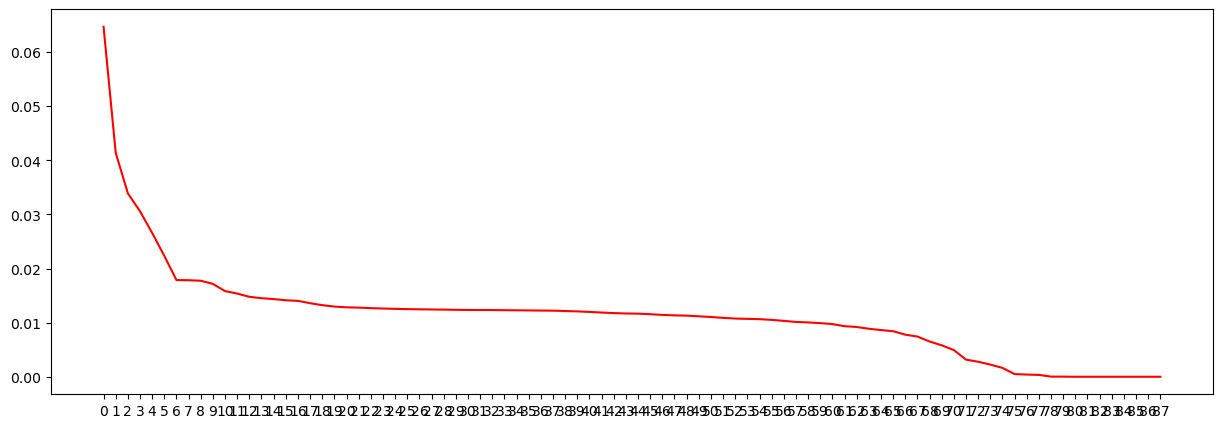

In [8]:
pca = PCA(n_components=X_train_scaled.shape[1]) # Instanciando o PCA com a quantidade de componentes iguais a quantidade de atributos a fim de visualizar o gráfico.
X_train_pca = pca.fit_transform(X_train_scaled)


#Técnica elbow para identificação do número ideal de componentes
plt.figure(figsize=(15, 5)) # criando um gráfico retangular para facilitar a visualização
plt.plot(pca.explained_variance_ratio_, color='r') # colocando a porcentagem de variância que cada componente nos trouxe
plt.xticks(np.arange(X_train_scaled.shape[1])) # mostrando todos os números no eixo x
plt.show() # mostrando o gráfico final

## A quantidade ideal de componentes é 6

In [9]:
pca = PCA(n_components=6) # Instanciação do pca com 6 componentes
X_train_pca = pca.fit_transform(X_train_scaled) # fit_transform nos dados de treino
X_test_pca = pca.transform(X_test_scaled) # transform nos dados de teste

display(f'Número original de features: {X_train_scaled.shape[1]}')
display(f'Número de features após PCA: {pca.n_components_}')

'Número original de features: 88'

'Número de features após PCA: 6'

## Etapa do treinamento do algoritmo com um algoritmo de aprendizagem supervisionada.

In [10]:
rfc_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1) #Instanciando o RandonForesterClassifier
rfc_model.fit(X_train_pca, y_train) #fitando o modelo
display('Treinamento concluído')

display('Score') # Score do treinamento dos dados.
display(rfc_model.score(X_test_pca, y_test))

y_pred = rfc_model.predict(X_test_pca) # Realizando a predição no conjunto de teste

df_comparacao = pd.DataFrame({'Valores Reais': y_test, 'Predições': y_pred}) # Dataframe para comparação lado a lado.
display('Comparação entre Valores Reais e Predições:')
display(df_comparacao.head(20))


'Treinamento concluído'

'Score'

0.7974252435120224

'Comparação entre Valores Reais e Predições:'

,Valores Reais,Predições
0,0,0
1,1,1
2,0,0
3,1,1
4,0,0
5,0,0
6,1,0
7,1,1
8,0,0
9,1,1


## Aplicando o conceito de pipelines e métricas específicas.

In [11]:
# Carregamento do dataset 
df_pipeline = pd.read_excel('csgo_round_snapshots.xlsx', index_col=False) 
# Além de remover duplicatas vou remover as colunas referentes as granadas.
df_pipeline = df_pipeline.drop_duplicates().drop(columns=df_pipeline.columns[df_pipeline.columns.str.contains('grenade')])
# Divisão do dataset
X_train, X_test, y_train, y_test = train_test_split(df_pipeline.drop('round_winner', axis=1), 
                                                    df_pipeline['round_winner'], 
                                                    test_size=0.25, 
                                                    random_state=42) 

## Se faz necesário a conversão dos dados contido no target antes do encapsulamento do pipeline.

In [12]:
# Aplicação do LabelEncoder para conversão dos dados do meu target (round_winner) em dados númericos
label_encoder = LabelEncoder() # Instanciação do LabelEncoder
y_train = label_encoder.fit_transform(y_train) # fit_transform apenas nos dados de treino para evitar o Leakage
y_test = label_encoder.transform(y_test) # transform no y_test
label_encoder.classes_ # Visualização da transformação dos dados (CT, T).

array(['CT', 'T'], dtype=object)

## Pipeline

In [13]:
pipe_1 = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ('scaler', StandardScaler()), 
    ('pca', PCA(n_components=6)),
    ('modelo', RandomForestClassifier())
]).fit(X_train, y_train)                 

y_pred = pipe_1.predict(X_test)
display(f'Resultados de y_pred: {y_pred}')

display(f'Score: {pipe_1.score(X_test, y_test)}')

display(f'Passos do pipeline')
pipe_1

'Resultados de y_pred: [0 1 1 ... 1 1 0]'

'Score: 0.774129827668415'

'Passos do pipeline'

Pipeline(steps=[('encoder',
                 OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
                ('scaler', StandardScaler()), ('pca', PCA(n_components=6)),
                ('modelo', RandomForestClassifier())])

## Usando métricas de classificação

In [14]:
display(f'Balanced accuracy: {balanced_accuracy_score(y_test, y_pred)}')
display(f'F1 Score: {f1_score(y_test, y_pred)}')

'Balanced accuracy: 0.7741200031312123'

'F1 Score: 0.7771954579049922'

# Conclusão
### Por ser tratar de classes balanceadas (CT,T) a acurácia é uma boa escolha de métrica,
### pois responde de forma clara a porcentagem de vezes que o modelo acerta o vencedor de cada round.
### Já o escore f1 nos permite tirar a prova como um complemento a acurácia garantindo que o modelo não está
### apenas "chutando" uma classe ligeiramente marjoritária.
###
### Com um acerto de aproximadamente 77% dos casos o modelo de fato apresenta resultados sólidos.
### O modelo também mostrou não ter um "lado preferido" prevendo os resultados de CT e T com a mesma qualidade.